In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import os;

In [3]:
df = pd.read_csv(r'/content/healthcare-dataset-stroke-data.csv')

In [4]:
df.head(5)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# Exploratory Data Analysis

In [5]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [6]:
df.dtypes

,0
id,int64
gender,object
age,float64
hypertension,int64
heart_disease,int64
ever_married,object
work_type,object
Residence_type,object
avg_glucose_level,float64
bmi,float64


In [7]:
df['bmi'].fillna(int(df['bmi'].mean()),inplace = True)
df.isnull().sum()

/tmp/ipython-input-622062109.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(int(df['bmi'].mean()),inplace = True)


,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0


In [8]:
df2 = df.drop('id',axis=1)
df2.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.0,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# ENCODING

In [9]:
categorical_cols = ['gender','ever_married','work_type','Residence_type','smoking_status']

In [10]:
from sklearn.preprocessing import OrdinalEncoder

In [11]:
oe = OrdinalEncoder()
df2[categorical_cols] = oe.fit_transform(df2[categorical_cols])

In [12]:
df2

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1.0,67.0,0,1,1.0,2.0,1.0,228.69,36.6,1.0,1
1,0.0,61.0,0,0,1.0,3.0,0.0,202.21,28.0,2.0,1
2,1.0,80.0,0,1,1.0,2.0,0.0,105.92,32.5,2.0,1
3,0.0,49.0,0,0,1.0,2.0,1.0,171.23,34.4,3.0,1
4,0.0,79.0,1,0,1.0,3.0,0.0,174.12,24.0,2.0,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,0.0,80.0,1,0,1.0,2.0,1.0,83.75,28.0,2.0,0
5106,0.0,81.0,0,0,1.0,3.0,1.0,125.20,40.0,2.0,0
5107,0.0,35.0,0,0,1.0,3.0,0.0,82.99,30.6,2.0,0
5108,1.0,51.0,0,0,1.0,2.0,0.0,166.29,25.6,1.0,0


In [13]:
df2[categorical_cols] = df2[categorical_cols].astype(int)

In [14]:
df2.dtypes

,0
gender,int64
age,float64
hypertension,int64
heart_disease,int64
ever_married,int64
work_type,int64
Residence_type,int64
avg_glucose_level,float64
bmi,float64
smoking_status,int64


In [15]:
df2['stroke'].value_counts()

,count
stroke,
0,4861
1,249


In [16]:
from sklearn.utils import resample

In [17]:
df_major = df2[(df2['stroke']==0)]
df_minor = df2[(df2['stroke']==1)]
df_minor_resmapled = resample(df_minor,replace=True,n_samples=4861,random_state=42)
df_resampled = pd.concat([df_minor_resmapled,df_major])

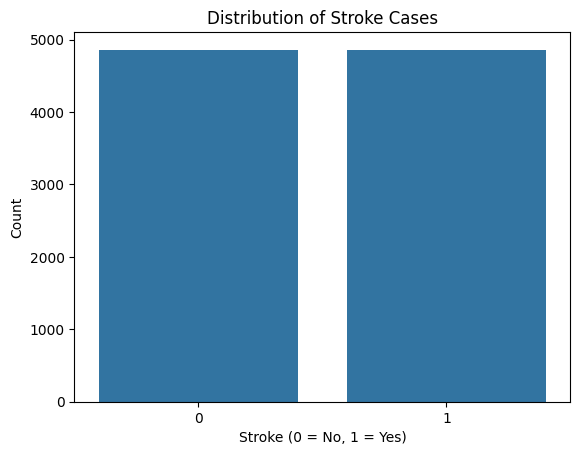

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='stroke', data=df_resampled)
plt.title('Distribution of Stroke Cases')
plt.xlabel('Stroke (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

<Axes: >

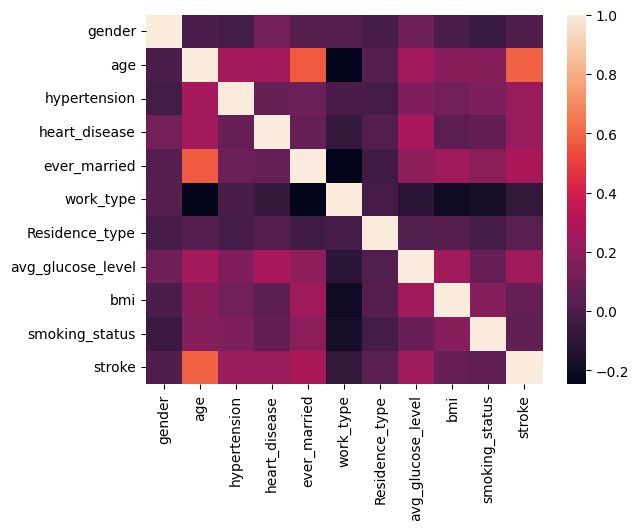

In [19]:
sns.heatmap(df_resampled.corr(), fmt='.2g')


In [20]:
x = df_resampled.iloc[:,:-1]
y = df_resampled['stroke']

In [21]:
from sklearn.model_selection import train_test_split,cross_val_score,cross_val_predict
from sklearn.metrics import accuracy_score
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=7)

# Decision Tree

In [22]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier()
dtc.fit(x_train,y_train)

DecisionTreeClassifier()

In [23]:
print("Accuracy Score :",round(dtc.score(x_test,y_test)*100,2),"%")

Accuracy Score : 97.12 %


In [24]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data and transform both training and testing data
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Choose number of components, for example 2 or 3
pca = PCA(n_components=2)

# Fit PCA on training data and transform both training and testing data
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)


Explained Variance Ratio: [0.23292602 0.12270833]


In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score

# Build the Neural Network model
model = Sequential()

# Input layer and first hidden layer
model.add(Dense(32, input_dim=x_train.shape[1], activation='relu'))

# Second hidden layer
model.add(Dense(16, activation='relu'))

# Output layer (for binary classification)
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(x_train, y_train, epochs=50, batch_size=10, validation_split=0.2)

# Evaluate the model on test data
loss, accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy: {:.2f}%".format(accuracy * 100))

# Optionally, make predictions
y_pred = model.predict(x_test)
y_pred = (y_pred > 0.5).astype(int)  # Convert probabilities to 0 or 1

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


623/623 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6694 - loss: 1.6660 - val_accuracy: 0.7487 - val_loss: 0.5110
Epoch 2/50
623/623 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7407 - loss: 0.5275 - val_accuracy: 0.7532 - val_loss: 0.5255
Epoch 3/50
623/623 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7406 - loss: 0.5359 - val_accuracy: 0.7641 - val_loss: 0.5020
Epoch 4/50
623/623 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7649 - loss: 0.5035 - val_accuracy: 0.7731 - val_loss: 0.4894
Epoch 5/50
623/623 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7513 - loss: 0.5112 - val_accuracy: 0.7731 - val_loss: 0.4896
Epoch 6/50
623/623 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7464 - loss: 0.5196 - val_accuracy: 0.7719 - val_loss: 0.4937
Epoch 7/50
623/623 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7635 - loss: 0.5013 - val_accuracy: 0.7590 - val_loss: 0.5110
Epoch 8/50
623/623 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7613 - loss: 0.5058 - val_accuracy: 0.7693 - val_

In [26]:
import joblib

# Save the trained Decision Tree model to a file
joblib.dump(dtc, 'decision_tree_model.pkl')

['decision_tree_model.pkl']

In [27]:
import joblib
import pandas as pd

# Load the saved Decision Tree model
dtc_loaded = joblib.load('decision_tree_model.pkl')

# Prepare new input data
# Use the encoded format like in your dataset
new_data = {
    'gender': [1.0],            # Example: 1 = Male, 0 = Female
    'age': [67.0],
    'hypertension': [0],
    'heart_disease': [1],
    'ever_married': [1.0],      # Example: 1 = Yes, 0 = No
    'work_type': [2.0],         # Encoded values depending on your dataset
    'Residence_type': [1.0],    # Example: 1 = Urban, 0 = Rural
    'avg_glucose_level': [228.69],
    'bmi': [36.6],
    'smoking_status': [1.0]     # Encoded smoking status
}

# Convert dictionary into DataFrame
new_df = pd.DataFrame(new_data)

# Make prediction
prediction = dtc_loaded.predict(new_df)

# Output result
if prediction[0] == 1:
    print("Prediction: Stroke likely.")
else:
    print("Prediction: Stroke unlikely.")


Prediction: Stroke likely.


In [28]:
import joblib
import pandas as pd

# Load the saved Decision Tree model
dtc_loaded = joblib.load('decision_tree_model.pkl')

# Prepare new input data with the values you provided
new_data = {
    'gender': [0.0],            # 0 = Female
    'age': [44.0],
    'hypertension': [0],
    'heart_disease': [0],
    'ever_married': [1.0],      # 1 = Yes
    'work_type': [0.0],         # Private (assuming encoding)
    'Residence_type': [1.0],    # 1 = Urban
    'avg_glucose_level': [85.28],
    'bmi': [26.2],
    'smoking_status': [0.0]     # Never smoked (assuming encoding)
}

# Convert dictionary into DataFrame
new_df = pd.DataFrame(new_data)

# Make prediction
prediction = dtc_loaded.predict(new_df)

# Output result
if prediction[0] == 1:
    print("Prediction: Stroke likely.")
else:
    print("Prediction: Stroke unlikely.")

Prediction: Stroke unlikely.


In [29]:
import joblib
import pandas as pd

# Load the saved Decision Tree model
dtc_loaded = joblib.load('decision_tree_model.pkl')

# Prepare new input data with the values you provided
new_data = {
    'gender': [1.0],            # 1 = Male
    'age': [80.0],              # 80 years old
    'hypertension': [0],        # No hypertension
    'heart_disease': [1],       # Has heart disease
    'ever_married': [1.0],      # 1 = Yes
    'work_type': [2.0],         # Self-employed (assuming encoding)
    'Residence_type': [0.0],    # 0 = Rural
    'avg_glucose_level': [105.92], # Glucose level
    'bmi': [32.5],              # BMI value
    'smoking_status': [2.0]     # Smokes (assuming encoding)
}

# Convert dictionary into DataFrame
new_df = pd.DataFrame(new_data)

# Make prediction
prediction = dtc_loaded.predict(new_df)

# Output result
if prediction[0] == 1:
    print("Prediction: Stroke")
else:
    print("Prediction: No Stroke")

Prediction: Stroke


In [30]:
import joblib
import pandas as pd

# Load the saved Decision Tree model
dtc_loaded = joblib.load('decision_tree_model.pkl')

# Prepare new input data with the values you provided
new_data = {
    'gender': [0.0],            # 0 = Female
    'age': [81.0],              # 81 years old
    'hypertension': [0],        # No hypertension
    'heart_disease': [0],       # No heart disease
    'ever_married': [1.0],      # 1 = Yes, Married
    'work_type': [3.0],         # Government job (assuming encoding)
    'Residence_type': [1.0],    # 1 = Urban
    'avg_glucose_level': [125.20], # Glucose level
    'bmi': [40.0],              # BMI value (obese category)
    'smoking_status': [2.0]     # Smokes (assuming encoding)
}

# Convert dictionary into DataFrame
new_df = pd.DataFrame(new_data)

# Make prediction
prediction = dtc_loaded.predict(new_df)

# Output result
if prediction[0] == 1:
    print("Prediction: Stroke")
else:
    print("Prediction: No Stroke")

Prediction: No Stroke
